In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print(np.__version__)

2.3.3


In [9]:
truth = [1, 0, 1, 0]
currents = [-0.1, 0.1, 10.1, 20.1]

lows = currents[truth]

TypeError: list indices must be integers or slices, not list

In [7]:
data = np.load('/gpfs/bwfor/work/ws/hd_gy283-my_data/relu/volt=0.0.npz')

[8.11078185]


explained: [0.14778839 0.14678723 0.14461889 0.14375384 0.14255332 0.1377963
 0.13670204]


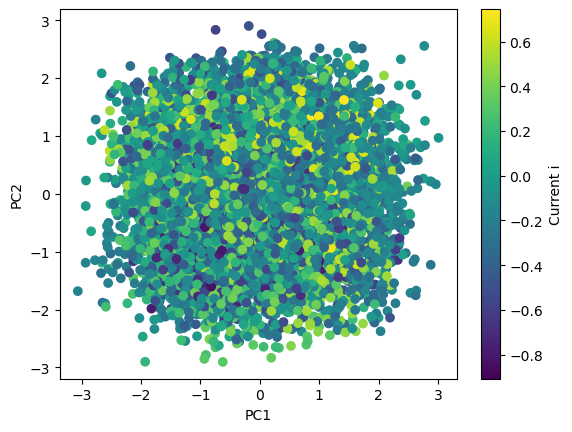

In [2]:
num_batches = 10
data_l = []
I_l = []
for i in range(num_batches):
    fp = f'/gpfs/bwfor/work/ws/hd_gy283-my_data/data_uni/batch_{i}.npz'
    batch = np.load(fp)
    data_l.append(batch['inputs'] )
    I_l.append(batch['currents'])

X = np.concatenate(data_l, axis=0)
y = np.concatenate(I_l, axis=0)
input_idx = 0

X = X[..., [i for i in range(X.shape[1]) if i != input_idx]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()

X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_
print(f'explained: {explained}')

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(label='Current i')
plt.show()

In [1]:
from sklearn.manifold import TSNE
from models import CondSM
import torch
import torch.nn as nn

state_dict = torch.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/data_gm_0/sm_gm_MSE.pth", weights_only=False, map_location='cpu')

model = CondSM(state_dict['layer_dims'], state_dict['dropout'], state_dict['batch_norm'])
model.load_state_dict(state_dict['model_state_dict'])

model.eval()

N = 100
v = torch.linspace(-1.5, 1.5, N).unsqueeze(-1)

func_list = []
param_list = []
num_funcs = 5_000
for i in range(num_funcs):
    cfg = np.random.uniform(-1.5, 1.5, 6)
    param_list.append(cfg.reshape(1, -1))
    c_v = torch.from_numpy(cfg).float().expand(N, -1)
    input_tensor = torch.cat([v, c_v], axis=-1)
    y_out = model(input_tensor).detach().cpu().numpy()
    func_list.append(y_out[:, 0].reshape(1,-1))
#print(func_list[0].shape)
X = np.concatenate(func_list, axis=0)
cfg_s = np.concatenate(param_list, axis=0)
#print(cfg_s.shape)
X_mean = X.mean(axis=1).reshape(-1, 1)
X_std = X.std(axis=1).reshape(-1, 1)
X_norm = (X - X_mean) / X_std

Y_list = []
for perpl in [5, 10, 20, 50, 100]:
    tsne = TSNE(
        n_components=2,
        perplexity=perpl,      # neighborhood size (try 5–50)
        learning_rate='auto',
        init='pca',
        metric='euclidean',
        max_iter=5000
    )
    Y_list.append(tsne.fit_transform(X))
    print(perpl)
print('Done')

KeyboardInterrupt: 

In [ ]:
V_1_vals = cfg_s[:, 5]

idx = 3
plt.figure(figsize=(6, 5))
sc = plt.scatter(Y_list[idx][:, 0], Y_list[idx][:, 1], c=V_1_vals, s=8)
plt.colorbar(sc, label="Config voltage 1")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE of surrogate functions, colored by V1")
plt.tight_layout()
plt.show()

Done


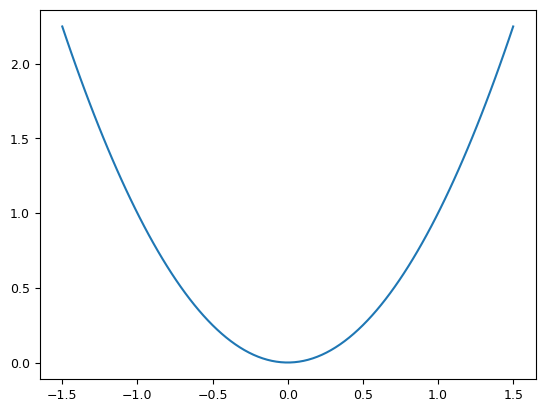

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy.stats import gaussian_kde
from models import CondSM
from utils import f_sm, sample_X, mse_loss_normalized, normalize_over_range

latex_txt_width = 404.02908 # in pt
in_per_pt = 1 / 72.27
width_in_pt = latex_txt_width * in_per_pt
height_in_pt = 0.618 * width_in_pt

import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 11,          # base font (affects cbar label unless overridden)
    "xtick.labelsize": 9,    # affects horizontal colorbar ticks
    "ytick.labelsize": 9,    # affects vertical colorbar ticks
    # Optional extras you may want:
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 9,
})

state_dict_0 = torch.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/models/sm_uni_na=200_MSE.pth", weights_only=False, map_location='cpu')

model_0 = CondSM(state_dict_0['layer_dims'], state_dict_0['dropout'], state_dict_0['batch_norm'])
model_0.load_state_dict(state_dict_0['model_state_dict'])

state_dict_1 = torch.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/data_vMB_own_pde_solver/sm_vMB_ring_MSE.pth", weights_only=False, map_location='cpu')

model_1 = CondSM(state_dict_1['layer_dims'], state_dict_1['dropout'], state_dict_1['batch_norm'])
model_1.load_state_dict(state_dict_1['model_state_dict'])

def target_f(x):

    f = nn.Sigmoid()
    #m = f(7*x)
    #m = torch.cos(3*x)
    m = x**2
    #m = -torch.exp(-1*x**2)

    return m

num_samples = 10_000
N = 100
in_range = torch.linspace(-1.5, 1.5, N).unsqueeze(-1)

mse_model_0 = []
mse_model_1 = []
inputs = []

model_0.eval()
model_1.eval()
for i in range(num_samples):
    thetas = torch.from_numpy(sample_X(1, d=6)).float().expand(N, -1)
    input_tensor = torch.cat([in_range, thetas], axis=1)
    inputs.append(input_tensor)
    with torch.no_grad():
        y_0 = model_0(input_tensor)
        y_1 = model_1(input_tensor)
        #y_0 = y_0[:, 0].unsqueeze(-1)
        #y_1 = y_1[:, 0].unsqueeze(-1)
        t = target_f(in_range)
        mse_model_0.append(mse_loss_normalized(y_0, t))
        mse_model_1.append(mse_loss_normalized(y_1, t))

print('Done')

plt.plot(in_range, target_f(in_range))

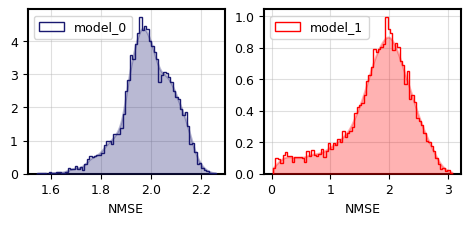

In [2]:
fig, ax = plt.subplots(ncols=2, figsize=(width_in_pt, height_in_pt * 0.618))

mse_model_0_a = np.array(mse_model_0)
mse_model_1_a = np.array(mse_model_1)

bins=75

ax[0].hist(mse_model_0_a, bins=bins, density=True, color='midnightblue', histtype='step', lw=1, label=f'model_0', zorder=4)
kde_0 = gaussian_kde(mse_model_0)
x_min, x_max = mse_model_0_a.min(), mse_model_0_a.max()
x_grid = np.linspace(x_min, x_max, 500)
ax[0].fill_between(
    x_grid,
    kde_0(x_grid),
    color='midnightblue',
    linewidth=1.5,
    alpha=.3,
    linestyle='-',
    zorder=5
)

ax[1].hist(mse_model_1_a, bins=bins, density=True, color='red', histtype='step', lw=1, label=f'model_1', zorder=4)
kde_1 = gaussian_kde(mse_model_1)
x_min, x_max = mse_model_1_a.min(), mse_model_1_a.max()
x_grid = np.linspace(x_min, x_max, 500)
ax[1].fill_between(
    x_grid,
    kde_1(x_grid),
    color='red',
    linewidth=1.5,
    alpha=.3,
    # linestyle='-',
    zorder=5
)

for i in range(2):
    #ax[i].tick_params(labelleft=False)
    #ax[i].set_yticks([])
    ax[i].spines[:].set_linewidth(1.5)
    ax[i].spines[:].set_linewidth(1.5)
    ax[i].legend()
    ax[i].legend()
    ax[i].set_xlabel('NMSE')
    ax[i].grid(zorder=1, alpha=.4)
plt.show()

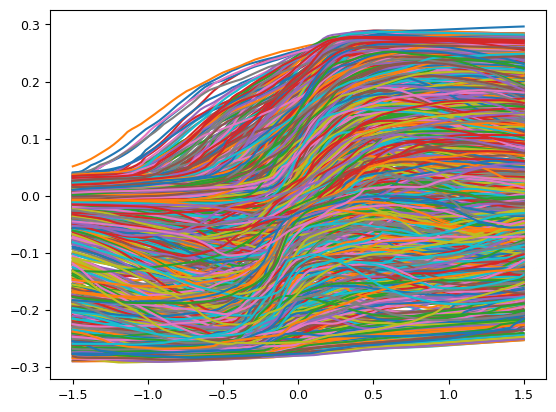

In [4]:
for i in range(1000):
    plt.plot(in_range, model_1(inputs[i]).detach())

1.498315691947937
6419
tensor([-1.5000,  1.4773,  1.3128, -0.0492, -0.1758, -1.3295, -0.3534])


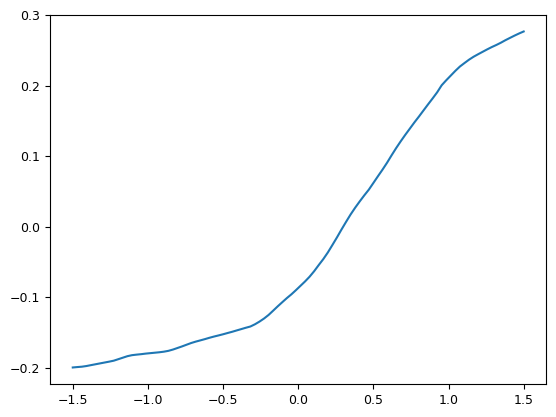

In [12]:
min_nmse = min(mse_model_0)
print(min_nmse)
min_index = mse_model_0.index(min_nmse)
print(min_index)

best_input = inputs[min_index]
print(best_input[0])
y_out = model_0(best_input).detach().cpu()

data = np.load('/gpfs/bwfor/work/ws/hd_gy283-my_data/gm_sim_1.npz')['current'] / 1.602e-19
#plt.plot(np.linspace(-1.5, 1.5, 50), data)
plt.plot(in_range, y_out)